In [1]:
2 + 2

4

In [2]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_community.document_loaders import PyPDFLoader
from langchain_openai import OpenAIEmbeddings

from typing import TypedDict, List, Annotated

g:\ml\.venv\Lib\site-packages\langchain_core\utils\pydantic.py:42: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1 import BaseModel as BaseModelV1
g:\ml\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\User\AppData\Local\Temp\ipykernel_3800\1229955290.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


In [3]:
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
docs = PyPDFLoader("../books/book.pdf").load()
docs

[Document(metadata={'producer': 'calibre 3.42.0 [https://calibre-ebook.com]', 'creator': 'calibre 3.42.0 [https://calibre-ebook.com]', 'creationdate': '2019-06-19T19:40:03+00:00', 'author': 'Aurélien Géron', 'title': 'Hands-On Machine Learning with Scikit-Learn and TensorFlow: Concepts, Tools, and Techniques to Build Intelligent Systems - PDFDrive.com', 'source': '../books/book.pdf', 'total_pages': 924, 'page': 0, 'page_label': '1'}, page_content=''),
 Document(metadata={'producer': 'calibre 3.42.0 [https://calibre-ebook.com]', 'creator': 'calibre 3.42.0 [https://calibre-ebook.com]', 'creationdate': '2019-06-19T19:40:03+00:00', 'author': 'Aurélien Géron', 'title': 'Hands-On Machine Learning with Scikit-Learn and TensorFlow: Concepts, Tools, and Techniques to Build Intelligent Systems - PDFDrive.com', 'source': '../books/book.pdf', 'total_pages': 924, 'page': 1, 'page_label': '2'}, page_content='Hands-On\tMachine\tLearning\twith\nScikit-Learn\tand\tTensorFlow\nConcepts,\tTools,\tand\tTe

In [33]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=900,
    chunk_overlap=100,
)

chunks = text_splitter.split_documents(docs)
print(f"Number of chunks: {len(chunks)}")
chunks[0]

Number of chunks: 1781


Document(metadata={'producer': 'calibre 3.42.0 [https://calibre-ebook.com]', 'creator': 'calibre 3.42.0 [https://calibre-ebook.com]', 'creationdate': '2019-06-19T19:40:03+00:00', 'author': 'Aurélien Géron', 'title': 'Hands-On Machine Learning with Scikit-Learn and TensorFlow: Concepts, Tools, and Techniques to Build Intelligent Systems - PDFDrive.com', 'source': '../books/book.pdf', 'total_pages': 924, 'page': 1, 'page_label': '2'}, page_content='Hands-On\tMachine\tLearning\twith\nScikit-Learn\tand\tTensorFlow\nConcepts,\tTools,\tand\tTechniques\tto\t\nBuild\tIntelligent\tSystems\nAurélien\tGéron')

In [34]:
from langchain_openai import OpenAIEmbeddings
import os

embeddings = OpenAIEmbeddings(
    api_key=os.environ["OPENROUTER_API_KEY"],
    base_url="https://openrouter.ai/api/v1" # OpenRouter base URL
)

In [35]:
from langchain_community.vectorstores import FAISS

vector_store = FAISS.from_documents(chunks, embedding=embeddings)

retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 3})

In [36]:
retriever.invoke("What is the machine learning?")

[Document(id='372d5778-6620-4c05-9f6a-fa5d6f2a8d21', metadata={'producer': 'calibre 3.42.0 [https://calibre-ebook.com]', 'creator': 'calibre 3.42.0 [https://calibre-ebook.com]', 'creationdate': '2019-06-19T19:40:03+00:00', 'author': 'Aurélien Géron', 'title': 'Hands-On Machine Learning with Scikit-Learn and TensorFlow: Concepts, Tools, and Techniques to Build Intelligent Systems - PDFDrive.com', 'source': '../books/book.pdf', 'total_pages': 924, 'page': 22, 'page_label': '23'}, page_content='What\tIs\tMachine\tLearning?\nMachine\tLearning\t\nis\tthe\tscience\t(and\tart)\tof\tprogramming\tcomputers\tso\tthey\ncan\t\nlearn\tfrom\tdata\n.\nHere\tis\ta\tslightly\tmore\tgeneral\tdefinition:\n[Machine\tLearning\tis\tthe]\tfield\tof\tstudy\tthat\tgives\tcomputers\tthe\tability\tto\nlearn\twithout\tbeing\texplicitly\tprogrammed.\nArthur\tSamuel,\t\n1959\nAnd\ta\tmore\tengineering-oriented\tone:\nA\tcomputer\tprogram\tis\tsaid\tto\tlearn\tfrom\texperience\tE\twith\trespect\tto\tsome\ntask\tT\ta

In [37]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    model="openai/gpt-4o-mini"
)

In [231]:
from typing import TypedDict, List


class CRAGState(TypedDict):
    question: str
    context: list[Document]
    answer: str

    strips:list[str]
    kept_strips:list[str]
    refined_context:str

    good_docs:list[str]
    verdict:str

    web_search_results:list[str]

In [232]:
def retriever_node(state:CRAGState):
    contexts = retriever.invoke(state["question"])
    return {"context": contexts}

In [233]:
from pydantic import BaseModel
from langchain_core.prompts import ChatPromptTemplate

class EvaluateDocs(BaseModel):
    score: float


evaluator_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "determine if this document is a good enough document for the question and give a score of how confident you are in your answer (0-1), the range can be float. for a completely irrelevant document give a score of 0 and for a completely relevant document give a score of 1"
    ),
    ("human", "the question: {question} and the document content: {content}")
])

evaluator_chain = evaluator_prompt | llm.with_structured_output(EvaluateDocs)


In [234]:
UPPER_THRESHOLD = 0.8
LOWER_THRESHOLD = 0.3

def evaluator_node(state:CRAGState):
    good_docs=[]

    contexts = [doc.page_content for doc in state["context"]]


    scored_docs = {}

    for content in contexts:
        score = evaluator_chain.invoke({"question": state["question"], "content": content}).score
        if score > LOWER_THRESHOLD:
            good_docs.append(content)
            scored_docs[content] = score
    
    for content, score in scored_docs.items():
        if score > UPPER_THRESHOLD:
            return {"good_docs": good_docs, "verdict": "correct"}
        
    if len(good_docs) == 0:
        return {"good_docs": [], "verdict": "incorrect"}
    else:
        return {"good_docs": good_docs, "verdict": "partial"}

In [235]:
def evaluator_router(state:CRAGState):
    if state["verdict"] == "correct":
        return "refine"
    else:
        return "search"

In [236]:
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_tavily import TavilySearch
from pydantic import BaseModel, Field
from dotenv import load_dotenv
import os

tavily_tool = TavilySearch(
    max_results=3,
    topic="general",
    search_depth="advanced"
)

load_dotenv()

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

class RewriteQuery(BaseModel):
    query: str = Field(description="The rewritten query")

query_llm = llm.with_structured_output(RewriteQuery)

def search_node(state: CRAGState):

    rewrite_query = query_llm.invoke([
        SystemMessage(content="Rewrite the user's question to be more specific and detailed for a web search, make sure it ius detailed but also at teh same time concise, just give the question nothing else is needed"),
        HumanMessage(content=state["question"])
        ])

    result = tavily_tool.invoke(rewrite_query.query)
    return {"web_search_results": result["results"]}

In [237]:
class KeeporDrop(BaseModel):
    keep: bool

class FilterResult(BaseModel):
    keep_indexes: list[int]

In [ ]:
filter_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "Select sentences that are useful for answering the question. "
        "Keep direct answers, important explanations, definitions, and useful examples. "
        "Drop only clearly irrelevant or noisy sentences."
    ),
    (
        "human",
        "Question: {question}\n\nSentences:\n{sentences}"
    )
])

filter_chain = filter_prompt | llm.with_structured_output(FilterResult)

In [239]:
import re

def split_sentences(text: str) -> list[str]:
    # Tabs -> spaces
    text = text.replace("\t", " ")

    # Normalize whitespace
    text = re.sub(r"[ ]+", " ", text)

    # Normalize excessive newlines
    text = re.sub(r"\n+", "\n", text)

    # Split on sentence endings OR meaningful line breaks
    sentences = re.split(
        r'(?<=[.!?])\s+(?=[A-Z\[])|\n(?=[A-Z])',
        text
    )

    return [
        sentence.strip()
        for sentence in sentences
        if len(sentence.strip()) > 10
    ]

In [240]:
def refine_node(state:CRAGState):
    context = list(state["good_docs"])

    if state.get("web_search_results"):
        for web_result in state["web_search_results"]:
            context.append(web_result["content"])
        
    combined_context = "\n".join(
        context
    )
    sentences = split_sentences(combined_context)

    numbered_sentences = "\n".join(
        f"{i}: {sentence}"
        for i, sentence in enumerate(sentences)
    )

    result = filter_chain.invoke({
        "question": state["question"],
        "sentences": numbered_sentences
    })

    print(result.keep_indexes)
    kept_sentences = [sentences[i] for i in result.keep_indexes if i < len(sentences)]
        
    refined_context = "\n".join(kept_sentences)
    return {
        "refined_context": refined_context,
        "strips": sentences,
        "kept_strips": kept_sentences
    }

In [ ]:

prompt = ChatPromptTemplate.from_messages([
    ("system", "Answer only from the context, if you don't know the answer, say 'I don't know'."),
    ("human", "the question: {question} and the context: {context}")
])

llm_chain = prompt | llm

In [242]:
def generate_node(state:CRAGState):
    answer = llm_chain.invoke({"question": state["question"], "context": state["refined_context"]})
    return {"answer": answer}

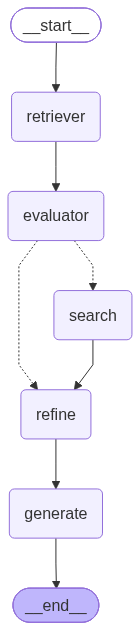

In [243]:
from langgraph.graph import StateGraph, END, START

graph = StateGraph(CRAGState)
graph.add_node("retriever", retriever_node)
graph.add_node("evaluator", evaluator_node)
graph.add_node("refine", refine_node)
graph.add_node("search", search_node)
graph.add_node("generate", generate_node)

graph.set_entry_point("retriever")
graph.add_edge("retriever", "evaluator")
graph.add_conditional_edges("evaluator", evaluator_router, {"refine": "refine", "search": "search"})
graph.add_edge("search", "refine")
graph.add_edge("refine", "generate")
graph.add_edge("generate", END)

app = graph.compile()

app


In [244]:
res = app.invoke({"question": "What is machine learning?"})

[1, 2, 5]


In [246]:
res

{'question': 'What is machine learning?',
 'context': [Document(id='372d5778-6620-4c05-9f6a-fa5d6f2a8d21', metadata={'producer': 'calibre 3.42.0 [https://calibre-ebook.com]', 'creator': 'calibre 3.42.0 [https://calibre-ebook.com]', 'creationdate': '2019-06-19T19:40:03+00:00', 'author': 'Aurélien Géron', 'title': 'Hands-On Machine Learning with Scikit-Learn and TensorFlow: Concepts, Tools, and Techniques to Build Intelligent Systems - PDFDrive.com', 'source': '../books/book.pdf', 'total_pages': 924, 'page': 22, 'page_label': '23'}, page_content='What\tIs\tMachine\tLearning?\nMachine\tLearning\t\nis\tthe\tscience\t(and\tart)\tof\tprogramming\tcomputers\tso\tthey\ncan\t\nlearn\tfrom\tdata\n.\nHere\tis\ta\tslightly\tmore\tgeneral\tdefinition:\n[Machine\tLearning\tis\tthe]\tfield\tof\tstudy\tthat\tgives\tcomputers\tthe\tability\tto\nlearn\twithout\tbeing\texplicitly\tprogrammed.\nArthur\tSamuel,\t\n1959\nAnd\ta\tmore\tengineering-oriented\tone:\nA\tcomputer\tprogram\tis\tsaid\tto\tlearn\tfr

In [227]:
res2 = app.invoke({"question": "What is the capital of France?"})
print(res2)

{'question': 'What is the capital of France?', 'context': [Document(id='f810c583-9ad6-4d1f-b776-d54eed440d8d', metadata={'producer': 'calibre 3.42.0 [https://calibre-ebook.com]', 'creator': 'calibre 3.42.0 [https://calibre-ebook.com]', 'creationdate': '2019-06-19T19:40:03+00:00', 'author': 'Aurélien Géron', 'title': 'Hands-On Machine Learning with Scikit-Learn and TensorFlow: Concepts, Tools, and Techniques to Build Intelligent Systems - PDFDrive.com', 'source': '../books/book.pdf', 'total_pages': 924, 'page': 4, 'page_label': '5'}, page_content='Preface'), Document(id='0b2a905b-2bd5-45c3-8f68-97d9d839aae6', metadata={'producer': 'calibre 3.42.0 [https://calibre-ebook.com]', 'creator': 'calibre 3.42.0 [https://calibre-ebook.com]', 'creationdate': '2019-06-19T19:40:03+00:00', 'author': 'Aurélien Géron', 'title': 'Hands-On Machine Learning with Scikit-Learn and TensorFlow: Concepts, Tools, and Techniques to Build Intelligent Systems - PDFDrive.com', 'source': '../books/book.pdf', 'total_

In [209]:
res = tavily_tool.invoke({"query": "What is the weather in Tokyo?"})["results"]

In [220]:
result = [r["content"] for r in res]


In [221]:
result


['## Moderate rainfall & Possible typhoon\n\nAbout 10 days in October see some rain on average, with a total amount of 200 mm (7.9 in). It is the last month when Tokyo is affected by typhoons. They visit 1 – 2 times on average, covering about 1 – 3 days each time. Typhoons, combined with the cold air from the north, cause some rainstorms that may incur river flooding and urban waterlogging, especially in early October. When the typhoon passes, occasional light rain and intermittent moderate rain become the main types. They won’t continuously bother your trip: each rainfall ends quickly. One thing to note is that the perceived temperature drops a little after the rain.  \n   \n Air humidity remains a moderate 65% in October, which feels neither dry nor humid.\n\n|  | [...] ## Mild temperature\n\nMeiji Jingu Shrine\n\nThe temperature shows a downward trend for the whole month. At the beginning, the daytime temperature remains a mild 25 – 28 degrees Celsius (77 – 82.4 degrees Fahrenheit).

In [228]:
res2

{'question': 'What is the capital of France?',
 'context': [Document(id='f810c583-9ad6-4d1f-b776-d54eed440d8d', metadata={'producer': 'calibre 3.42.0 [https://calibre-ebook.com]', 'creator': 'calibre 3.42.0 [https://calibre-ebook.com]', 'creationdate': '2019-06-19T19:40:03+00:00', 'author': 'Aurélien Géron', 'title': 'Hands-On Machine Learning with Scikit-Learn and TensorFlow: Concepts, Tools, and Techniques to Build Intelligent Systems - PDFDrive.com', 'source': '../books/book.pdf', 'total_pages': 924, 'page': 4, 'page_label': '5'}, page_content='Preface'),
  Document(id='0b2a905b-2bd5-45c3-8f68-97d9d839aae6', metadata={'producer': 'calibre 3.42.0 [https://calibre-ebook.com]', 'creator': 'calibre 3.42.0 [https://calibre-ebook.com]', 'creationdate': '2019-06-19T19:40:03+00:00', 'author': 'Aurélien Géron', 'title': 'Hands-On Machine Learning with Scikit-Learn and TensorFlow: Concepts, Tools, and Techniques to Build Intelligent Systems - PDFDrive.com', 'source': '../books/book.pdf', 'tot